# Building Up to Consistent Rate Estimation

This notebook walks through the ideas behind
`vivarium_csu_alzheimers/data/consistent_rates.py` one piece at a time.
We build from the simplest possible Bayesian rate estimation up to a full
compartmental ODE model with consistency constraints, matching the approach
used in the Alzheimer's simulation.

**Outline:**

1. **Part 1 -- One rate, one prior:** Fit a single age-varying rate to noisy observations.
2. **Part 2 -- Two rates with a consistency link:** Prevalence and incidence must agree with each other; we tie them with a simple *difference-equation* consistency constraint.
3. **Part 3 -- The full ODE system:** S -> BBBM -> MCI -> Dementia with mortality, fit to GBD-like data with an ODE consistency penalty.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")  # silences the CUDA-fallback notice at import time

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro import infer
import matplotlib.pyplot as plt
import matplotlib
from diffrax import ODETerm, Dopri5, SaveAt, diffeqsolve

numpyro.set_host_device_count(1)

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['font.size'] = 12

---
## Part 1: Fitting a Single Rate to Noisy Data

Suppose we observe an age-varying rate (like disease prevalence) at several ages,
each with some measurement noise. We want to infer the underlying rate.

This is the job of two functions in `consistent_rates.py`:
- **`at_param`** -- creates a piecewise-constant rate function indexed by age
- **`data_model`** -- adds a Gaussian likelihood comparing predictions to observations

### Synthetic "observed" data

Let's make up a prevalence curve that rises with age, mimicking dementia prevalence:

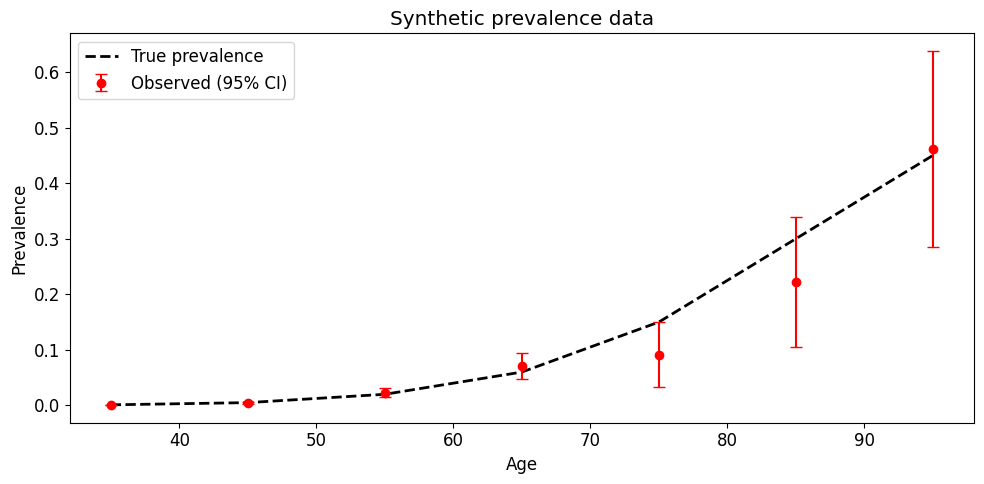

In [2]:
# Age groups (midpoints) and a "true" prevalence that rises with age
ages = np.array([35, 45, 55, 65, 75, 85, 95])
true_prev = np.array([0.001, 0.005, 0.02, 0.06, 0.15, 0.30, 0.45])

# Simulate noisy observations
rng = np.random.default_rng(42)
obs_se = 0.2 * true_prev  # measurement error scales with the rate
obs_mean = np.clip(true_prev + rng.normal(0, obs_se), 1e-6, 1)

fig, ax = plt.subplots()
ax.plot(ages, true_prev, 'k--', lw=2, label='True prevalence')
ax.errorbar(ages, obs_mean, yerr=1.96*obs_se, fmt='ro', capsize=4, label='Observed (95% CI)')
ax.set(xlabel='Age', ylabel='Prevalence', title='Synthetic prevalence data')
ax.legend()
plt.tight_layout()

### The NumPyro model: prior + likelihood

We put a `Uniform(0, 1)` prior on each age-knot value. This is a deliberately
vague prior -- it says only "the rate is between 0 and 1" and leaves the
likelihood (and later, the consistency constraint) to do the work.

The likelihood says: the observed data point at each age is normally distributed
around the model's predicted rate, with the known standard error.

This mirrors exactly what `consistent_rates.py` does for each rate type.

In [3]:
def model_single_rate():
    """NumPyro model: one rate (prevalence) with a vague prior, fit to data."""
    # Prior: one free parameter per age knot, uniform on [0, 1]
    knot_vals = numpyro.sample(
        "prev",
        dist.Uniform(jnp.zeros(len(ages)), jnp.ones(len(ages))),
    )

    # Likelihood: observed data ~ Normal(predicted, se)
    numpyro.sample(
        "prev_obs",
        dist.Normal(loc=knot_vals, scale=jnp.array(obs_se)),
        obs=jnp.array(obs_mean),  # <-- conditioning on the observed data
    )

In [4]:
# Run MCMC
kernel = infer.NUTS(model_single_rate)
mcmc = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=1, progress_bar=False)
mcmc.run(jax.random.PRNGKey(0))
samples_1 = mcmc.get_samples()

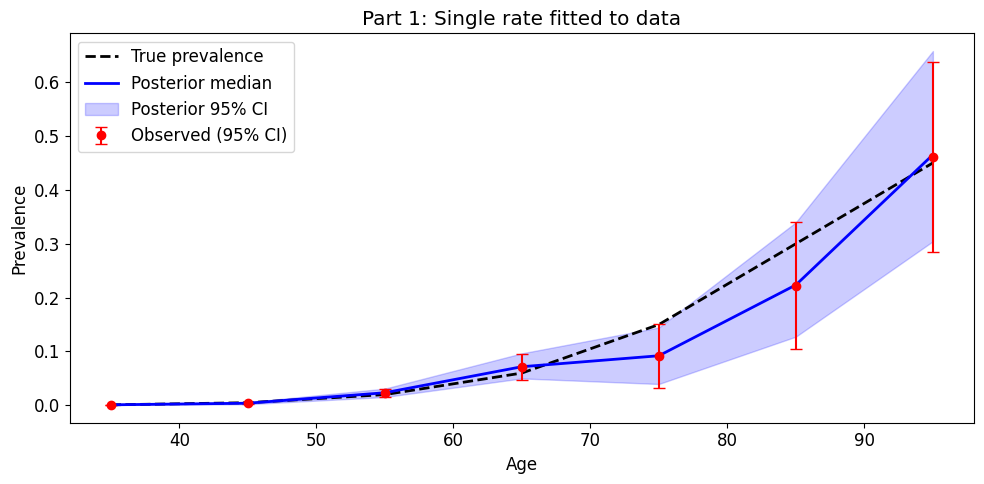

In [5]:
# Plot posterior
prev_samples = np.array(samples_1["prev"])  # shape (500, 7)

fig, ax = plt.subplots()
ax.plot(ages, true_prev, 'k--', lw=2, label='True prevalence')
ax.errorbar(ages, obs_mean, yerr=1.96*obs_se, fmt='ro', capsize=4, label='Observed (95% CI)')

# Posterior median and 95% interval
post_med = np.median(prev_samples, axis=0)
post_lo = np.percentile(prev_samples, 2.5, axis=0)
post_hi = np.percentile(prev_samples, 97.5, axis=0)
ax.plot(ages, post_med, 'b-', lw=2, label='Posterior median')
ax.fill_between(ages, post_lo, post_hi, alpha=0.2, color='blue', label='Posterior 95% CI')

ax.set(xlabel='Age', ylabel='Prevalence', title='Part 1: Single rate fitted to data')
ax.legend()
plt.tight_layout()

**Takeaway:** With just a prior and a likelihood, MCMC recovers the rate from noisy data.
The posterior concentrates around the observations -- exactly what `data_model()` in the
production code does for each rate individually.

But there's no connection *between* rates yet. Prevalence, incidence, and mortality are
each fit in isolation. They might be internally contradictory.

---
## Part 2: Two Rates With a Consistency Constraint

In a simple two-state model (Healthy vs. Diseased), prevalence and incidence
are linked: the faster people develop disease, the more prevalent it becomes.
We can write this relationship directly on the age grid we already use for our
knots -- no continuous-time ODE required.

### The difference equation

Between consecutive age knots $a_k$ and $a_{k+1} = a_k + \Delta a$, a simple
bookkeeping argument says: the prevalence at the next age equals the prevalence
at this age *plus* the fraction of currently-healthy people who become diseased
during the interval (for a chronic disease with no remission and ignoring
mortality):

$$p_{k+1} \;=\; p_k \;+\; \Delta a \cdot i_k \cdot (1 - p_k).$$

This is a **discrete-time difference equation**. It is the forward-Euler
approximation of $dp/da = i(1-p)$, but for the purposes of this section we
treat it as the definition of the consistency relationship -- it is exact on
the age grid we actually work with.

*If we know incidence at every age, we can compute what prevalence must be.*
If our independently-estimated prevalence disagrees, something is wrong.

### Approach: Soft consistency penalty

Rather than forcing exact agreement (a hard constraint), we add a **soft
penalty**: at each age step, the prevalence predicted by the difference
equation should be close to the estimated prevalence at the next age.
Disagreement is penalized via a Normal(0, sigma) factor term.

This is exactly the same idea as `numpyro.factor("ode_consistency_factor", log_pr)`
in the production code -- but here with just two rates and a one-line update.

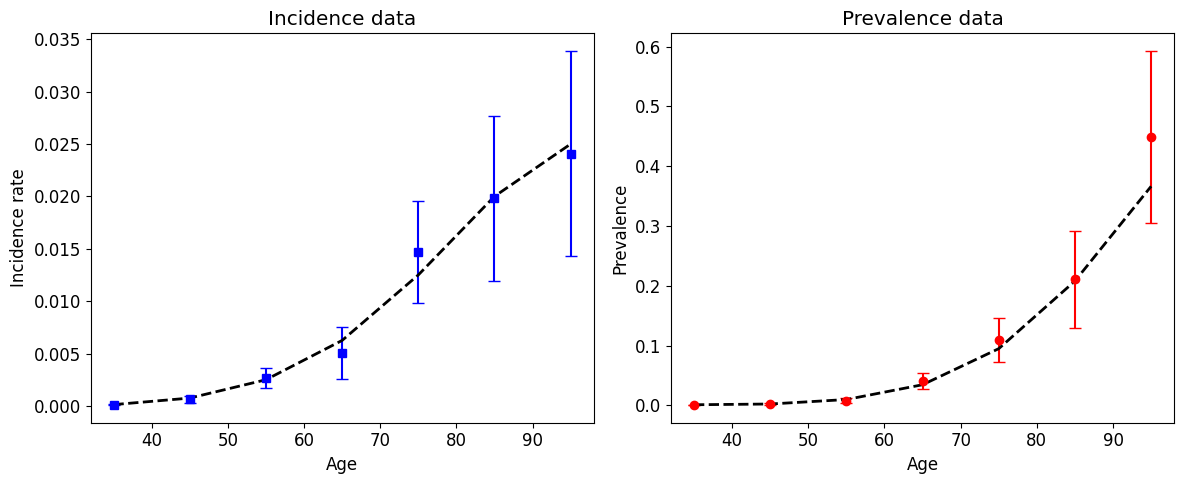

In [6]:
# Synthetic data for both prevalence and incidence
# True incidence generates the true prevalence via the difference equation
#   p[k+1] = p[k] + da * i[k] * (1 - p[k])
true_inc = 0.25 * np.array([0.0005, 0.003, 0.01, 0.025, 0.05, 0.08, 0.10])

da = 10  # age step between knots
true_prev_2 = np.zeros(len(ages))
true_prev_2[0] = 0.001  # small non-zero seed so SE scales cleanly at age 35
for k in range(1, len(ages)):
    true_prev_2[k] = true_prev_2[k-1] + da * true_inc[k-1] * (1 - true_prev_2[k-1])
true_prev_2 = np.clip(true_prev_2, 0, 1)

# Add noise (SE = 20% of the rate -- same pattern as Part 1)
obs_prev_se = 0.2 * true_prev_2
obs_prev_mean = np.clip(true_prev_2 + rng.normal(0, obs_prev_se), 1e-6, 1)
obs_inc_se = 0.2 * true_inc
obs_inc_mean = np.clip(true_inc + rng.normal(0, obs_inc_se), 1e-6, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].errorbar(ages, obs_inc_mean, yerr=1.96*obs_inc_se, fmt='bs', capsize=4)
axes[0].plot(ages, true_inc, 'k--', lw=2)
axes[0].set(xlabel='Age', ylabel='Incidence rate', title='Incidence data')
axes[1].errorbar(ages, obs_prev_mean, yerr=1.96*obs_prev_se, fmt='ro', capsize=4)
axes[1].plot(ages, true_prev_2, 'k--', lw=2)
axes[1].set(xlabel='Age', ylabel='Prevalence', title='Prevalence data')
plt.tight_layout()

In [7]:
def model_two_rates_no_consistency():
    """Fit prevalence and incidence independently -- no consistency link."""
    prev = numpyro.sample("prev", dist.Uniform(
        jnp.zeros(len(ages)), jnp.ones(len(ages))))
    inc = numpyro.sample("inc", dist.Uniform(
        jnp.zeros(len(ages)), jnp.ones(len(ages))))

    numpyro.sample("prev_obs", dist.Normal(prev, jnp.array(obs_prev_se)),
                   obs=jnp.array(obs_prev_mean))
    numpyro.sample("inc_obs", dist.Normal(inc, jnp.array(obs_inc_se)),
                   obs=jnp.array(obs_inc_mean))


def model_two_rates_with_consistency():
    """Fit prevalence and incidence WITH a soft difference-equation
    consistency constraint.
    """
    prev = numpyro.sample("prev", dist.Uniform(
        jnp.zeros(len(ages)), jnp.ones(len(ages))))
    inc = numpyro.sample("inc", dist.Uniform(
        jnp.zeros(len(ages)), jnp.ones(len(ages))))

    # Data likelihood (same as above)
    numpyro.sample("prev_obs", dist.Normal(prev, jnp.array(obs_prev_se)),
                   obs=jnp.array(obs_prev_mean))
    numpyro.sample("inc_obs", dist.Normal(inc, jnp.array(obs_inc_se)),
                   obs=jnp.array(obs_inc_mean))

    # --- Consistency constraint ---
    # For each adjacent pair of ages, the difference equation says:
    #   prev[k+1] ~ prev[k] + da * inc[k] * (1 - prev[k])
    # Penalize disagreement in log space.
    sigma = 0.01  # how tightly to enforce consistency
    for k in range(len(ages) - 1):
        prev_predicted = prev[k] + da * inc[k] * (1 - prev[k])
        error = jnp.log(jnp.clip(prev[k+1], 1e-12)) - jnp.log(jnp.clip(prev_predicted, 1e-12))
        numpyro.factor(f"consistency_{k}", dist.Normal(0, sigma).log_prob(error))

In [8]:
# Fit both models
results = {}
for name, model_fn in [("no_consistency", model_two_rates_no_consistency),
                        ("with_consistency", model_two_rates_with_consistency)]:
    kernel = infer.NUTS(model_fn)
    mcmc = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=1, progress_bar=False)
    mcmc.run(jax.random.PRNGKey(1))
    results[name] = mcmc.get_samples()

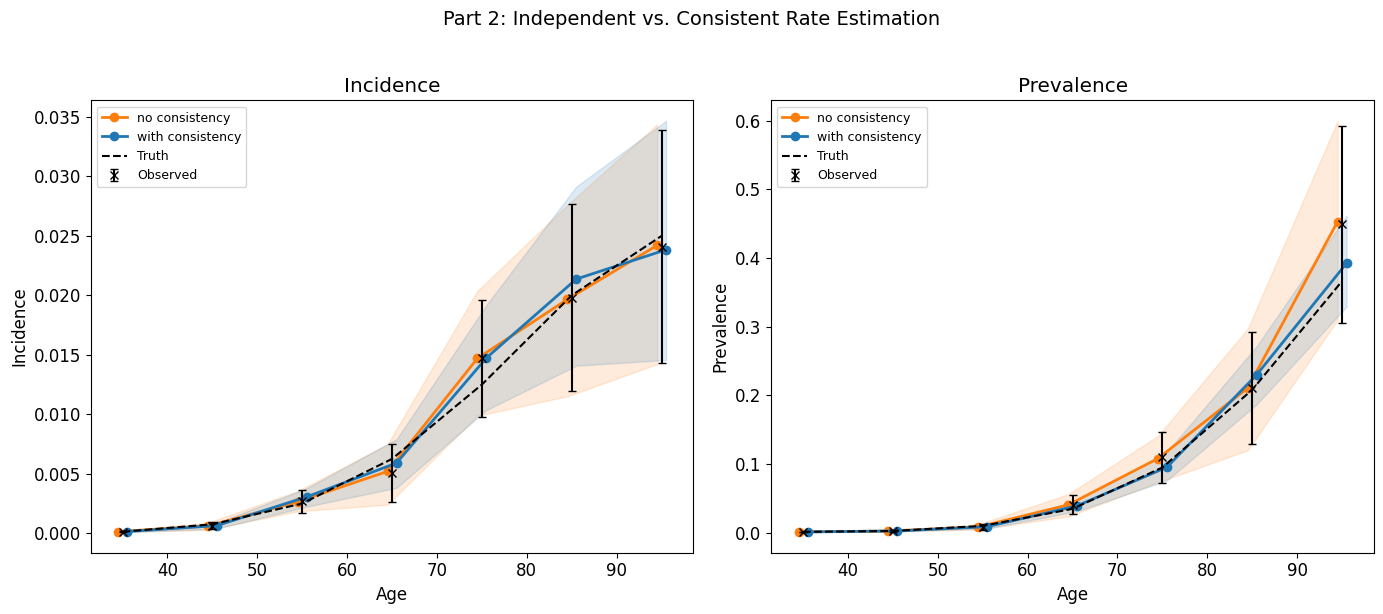

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for col, (name, color) in enumerate([("no_consistency", "tab:orange"),
                                      ("with_consistency", "tab:blue")]):
    for row, (param, obs_m, obs_s, truth, ylabel) in enumerate([
        ("inc", obs_inc_mean, obs_inc_se, true_inc, "Incidence"),
        ("prev", obs_prev_mean, obs_prev_se, true_prev_2, "Prevalence"),
    ]):
        ax = axes[row]
        samp = np.array(results[name][param])
        med = np.median(samp, axis=0)
        lo = np.percentile(samp, 2.5, axis=0)
        hi = np.percentile(samp, 97.5, axis=0)
        offset = -0.5 if col == 0 else 0.5
        label = name.replace('_', ' ')
        ax.plot(ages + offset, med, 'o-', color=color, lw=2, label=label)
        ax.fill_between(ages + offset, lo, hi, alpha=0.15, color=color)

for row, (param, obs_m, obs_s, truth, ylabel) in enumerate([
    ("inc", obs_inc_mean, obs_inc_se, true_inc, "Incidence"),
    ("prev", obs_prev_mean, obs_prev_se, true_prev_2, "Prevalence"),
]):
    ax = axes[row]
    ax.errorbar(ages, obs_m, yerr=1.96*obs_s, fmt='kx', capsize=3, label='Observed', zorder=5)
    ax.plot(ages, truth, 'k--', lw=1.5, label='Truth')
    ax.set(xlabel='Age', ylabel=ylabel, title=ylabel)
    ax.legend(fontsize=9)

fig.suptitle('Part 2: Independent vs. Consistent Rate Estimation', fontsize=14, y=1.02)
plt.tight_layout()

**What to see:** The consistency constraint "borrows strength" between the two
rates. Where the data for one rate is noisy, information from the other rate
(through the difference-equation relationship) pulls the estimate toward a
consistent solution.

The key mechanism is `numpyro.factor()` -- it adds a penalty (a log-probability
term) to the model's joint density. MCMC then explores the posterior that
balances fitting the data *and* satisfying the consistency constraint.

### Visualizing the consistency error

Let's directly measure how well the difference-equation relationship is
satisfied in each posterior. For each age step, we compute the residual --
how much the forward-stepped prevalence disagrees with the estimated
prevalence at the next age.

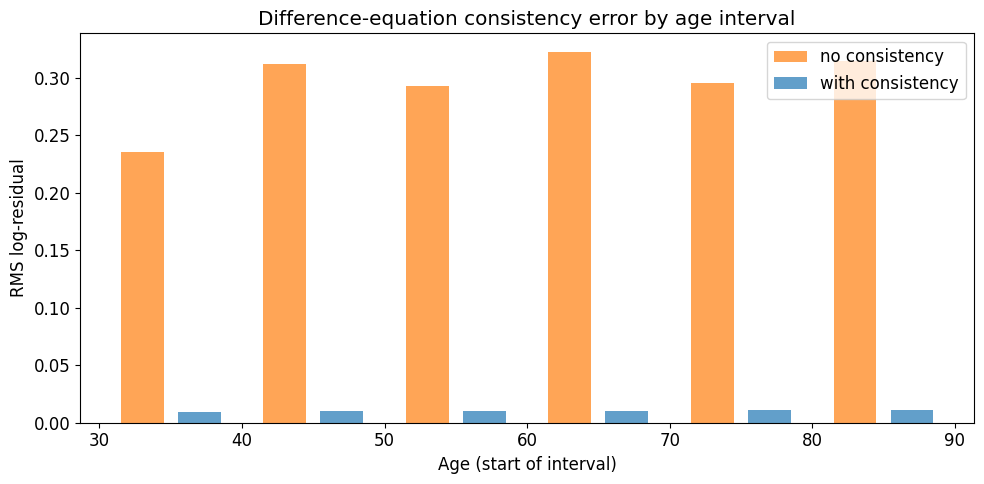

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, color in [("no_consistency", "tab:orange"), ("with_consistency", "tab:blue")]:
    prev_s = np.array(results[name]["prev"])
    inc_s = np.array(results[name]["inc"])
    # Residual: prev[k+1] vs prev[k] + da * inc[k] * (1 - prev[k])
    pred_next = prev_s[:, :-1] + da * inc_s[:, :-1] * (1 - prev_s[:, :-1])
    residual = np.log(np.clip(prev_s[:, 1:], 1e-12, None)) - np.log(np.clip(pred_next, 1e-12, None))
    rms = np.sqrt(np.mean(residual**2, axis=0))
    label = name.replace('_', ' ')
    ax.bar(ages[:-1] + (2 if name == "with_consistency" else -2), rms,
           width=3, color=color, alpha=0.7, label=label)

ax.set(xlabel='Age (start of interval)', ylabel='RMS log-residual',
       title='Difference-equation consistency error by age interval')
ax.legend()
plt.tight_layout()

---
## Part 3: The Full ODE System

The Alzheimer's model in `consistent_rates.py` has **four compartments** plus a cumulative
incidence counter:

```
  S (Susceptible)
  |                        h_S_to_BBBM
  v
  BBBM (Blood-Based Biomarker positive)
  |                        h_BBBM_to_MCI = 1 / BBBM_AVG_DURATION
  v
  MCI (Mild Cognitive Impairment)
  |                        h_MCI_to_dementia = 1 / MCI_AVG_DURATION
  v
  D (Dementia)
```

Each compartment also loses people to background mortality $m$, and the
Dementia compartment has additional excess mortality $f$.

### The ODE

$$\frac{dS}{dt} = -m \cdot S - h_{S \to BBBM} \cdot S$$

$$\frac{d(BBBM)}{dt} = h_{S \to BBBM} \cdot S - m \cdot BBBM - h_{BBBM \to MCI} \cdot BBBM$$

$$\frac{d(MCI)}{dt} = h_{BBBM \to MCI} \cdot BBBM - m \cdot MCI - h_{MCI \to D} \cdot MCI$$

$$\frac{dD}{dt} = h_{MCI \to D} \cdot MCI - (m + f) \cdot D$$

$$\frac{d(\text{new\_D})}{dt} = h_{MCI \to D} \cdot MCI$$

### What the code does

1. Give every rate its own prior and data likelihood (Parts 1 & 2 above)
2. Integrate the ODE forward from age $a$ to $a + 5$ (one GBD age group)
3. Compare the ODE solution at $a + 5$ to the model's estimated rates at $a + 5$
4. Penalize the discrepancy via `numpyro.factor()`

### Let's build it step by step

In [11]:
# First, let's just explore the ODE forward integration with known rates.
# This shows what the ODE does -- no inference yet.

# Disease parameters
BBBM_AVG_DURATION = 6.33   # years in BBBM state
MCI_AVG_DURATION = 3.85    # years in MCI state
h_BBBM_to_MCI = 1.0 / BBBM_AVG_DURATION
h_MCI_to_D = 1.0 / MCI_AVG_DURATION

print(f"h_BBBM_to_MCI = {h_BBBM_to_MCI:.4f} /year")
print(f"h_MCI_to_D    = {h_MCI_to_D:.4f} /year")

h_BBBM_to_MCI = 0.1580 /year
h_MCI_to_D    = 0.2597 /year


In [12]:
def ode_rhs(t, y, args):
    """Right-hand side of the 4-compartment ODE.
    
    This is the same function as ode_function in consistent_rates.py.
    """
    S, BBBM, MCI, D, new_D = y
    h_S_to_BBBM, h_BBBM_to_MCI, h_MCI_to_D, f, m = args
    return (
        -m * S - h_S_to_BBBM * S,                                       # dS/dt
        h_S_to_BBBM * S - m * BBBM - h_BBBM_to_MCI * BBBM,              # dBBBM/dt
        h_BBBM_to_MCI * BBBM - m * MCI - h_MCI_to_D * MCI,              # dMCI/dt
        h_MCI_to_D * MCI - (m + f) * D,                                 # dD/dt
        h_MCI_to_D * MCI,                                               # d(new_D)/dt
    )


# Integrate from age 60 to 65 with constant rates
h_S_to_BBBM_example = 0.03
f_example = 0.05
m_example = 0.02

# Initial condition: 90% susceptible, 5% BBBM, 3% MCI, 2% Dementia
y0 = (0.90, 0.05, 0.03, 0.02, 0.0)

# Solve ODE over a range of time points for visualization
t_span = jnp.linspace(0, 30, 300)
term = ODETerm(ode_rhs)
solver = Dopri5()
saveat = SaveAt(ts=t_span)

solution = diffeqsolve(
    term, solver,
    t0=0, t1=30, dt0=0.1,
    y0=y0,
    saveat=saveat,
    args=[h_S_to_BBBM_example, h_BBBM_to_MCI, h_MCI_to_D, f_example, m_example],
)

S, BBBM, MCI, D, new_D = [np.array(solution.ys[i]) for i in range(5)]

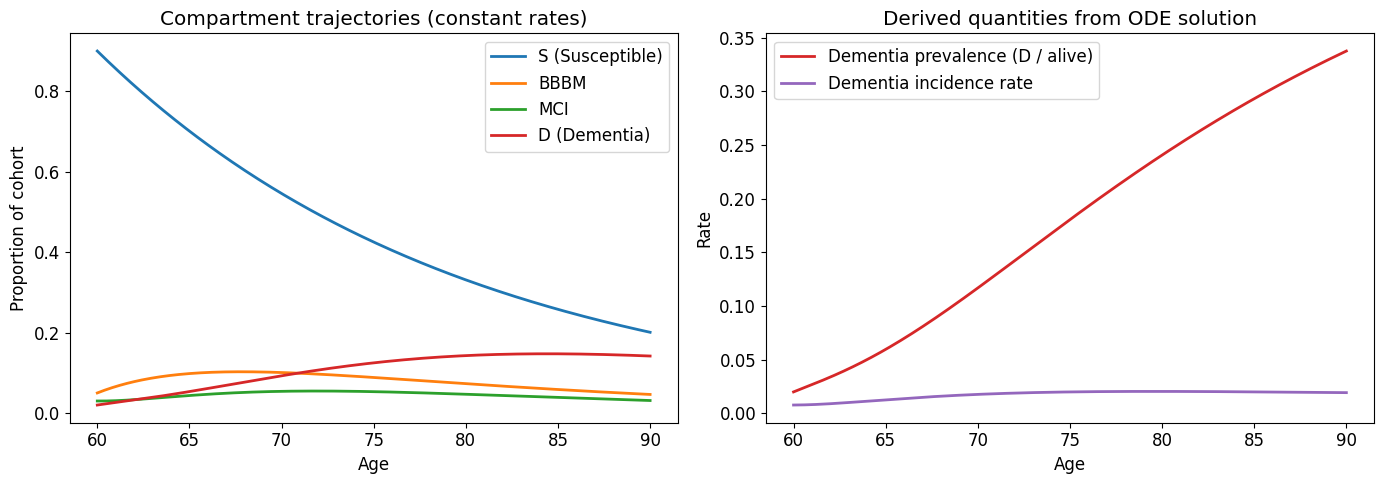

In [13]:
t = np.array(t_span)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t + 60, S, label='S (Susceptible)', lw=2)
ax.plot(t + 60, BBBM, label='BBBM', lw=2)
ax.plot(t + 60, MCI, label='MCI', lw=2)
ax.plot(t + 60, D, label='D (Dementia)', lw=2)
ax.set(xlabel='Age', ylabel='Proportion of cohort',
       title='Compartment trajectories (constant rates)')
ax.legend()

ax = axes[1]
alive = S + BBBM + MCI + D
ax.plot(t + 60, D / alive, label='Dementia prevalence (D / alive)', lw=2, color='tab:red')
# Instantaneous incidence ≈ new_D / (dt * alive)
inst_inc = np.gradient(new_D, t) / alive
ax.plot(t + 60, inst_inc, label='Dementia incidence rate', lw=2, color='tab:purple')
ax.set(xlabel='Age', ylabel='Rate',
       title='Derived quantities from ODE solution')
ax.legend()

plt.tight_layout()

### The consistency check

The production code does the following at each age:

1. **Initialize** compartments from the model's estimated rates at age $a$
2. **Integrate** the ODE forward by $dt = 5$ years (one age group)
3. **Compare** the ODE-predicted compartment fractions to the model's estimates at age $a + 5$
4. **Penalize** the log-ratio of predicted vs. estimated

Four quantities are checked:
- `delta_BBBM` -- fraction of prevalent cases that are in BBBM state
- `delta_MCI` -- fraction of prevalent cases that are in MCI state  
- `p_dementia` -- dementia prevalence among the alive
- `i` -- incidence rate of dementia

Let's see this for a single age step:

In [14]:
# Demonstrate the consistency check for one age step (60 -> 65)

# "Estimated" values at age 60 (these would come from the model parameters)
p_60 = 0.08         # overall disease prevalence at age 60
delta_BBBM_60 = 0.4  # 40% of prevalent cases are in BBBM
delta_MCI_60 = 0.3   # 30% are in MCI
# So dementia = 1 - 0.4 - 0.3 = 30% of prevalent cases

# Initialize ODE compartments from these
S0 = 1.0 - p_60
BBBM0 = p_60 * delta_BBBM_60
MCI0 = p_60 * delta_MCI_60
D0 = p_60 * (1 - delta_BBBM_60 - delta_MCI_60)

print(f"Initial compartments at age 60:")
print(f"  S    = {S0:.3f}")
print(f"  BBBM = {BBBM0:.3f}")
print(f"  MCI  = {MCI0:.3f}")
print(f"  D    = {D0:.3f}")
print(f"  Sum  = {S0+BBBM0+MCI0+D0:.3f}")

# Integrate forward 5 years
dt = 5
sol = diffeqsolve(
    ODETerm(ode_rhs), Dopri5(),
    t0=0, t1=dt, dt0=0.5,
    y0=(S0, BBBM0, MCI0, D0, 0.0),
    saveat=SaveAt(t0=False, t1=True),
    args=[h_S_to_BBBM_example, h_BBBM_to_MCI, h_MCI_to_D, f_example, m_example],
)

S5, BBBM5, MCI5, D5, new_D5 = [float(sol.ys[i][0]) for i in range(5)]
alive5 = S5 + BBBM5 + MCI5 + D5
disease5 = BBBM5 + MCI5 + D5

print(f"\nODE-predicted at age 65:")
print(f"  delta_BBBM = BBBM/(BBBM+MCI+D) = {BBBM5/disease5:.4f}")
print(f"  delta_MCI  = MCI/(BBBM+MCI+D)  = {MCI5/disease5:.4f}")
print(f"  p_dementia = D/alive            = {D5/alive5:.4f}")
print(f"  incidence  = new_D/(dt*alive)    = {new_D5/(dt*alive5):.6f}")

# Now: if the MODEL's estimates at age 65 differ from these,
# the consistency penalty kicks in!
print(f"\nIf the model says p_dementia(65) = 0.05 but ODE says {D5/alive5:.4f},")
print(f"the log-ratio penalty = {abs(np.log(0.05) - np.log(D5/alive5)):.4f}")

Initial compartments at age 60:
  S    = 0.920
  BBBM = 0.032
  MCI  = 0.024
  D    = 0.024
  Sum  = 1.000



ODE-predicted at age 65:
  delta_BBBM = BBBM/(BBBM+MCI+D) = 0.5146
  delta_MCI  = MCI/(BBBM+MCI+D)  = 0.2119
  p_dementia = D/alive            = 0.0549
  incidence  = new_D/(dt*alive)    = 0.008401

If the model says p_dementia(65) = 0.05 but ODE says 0.0549,
the log-ratio penalty = 0.0931


### Putting it all together: the full model

Now we build a complete model with synthetic data that mirrors the structure of
`BBBM_AD_Model.fit()`. We use 8 age groups and fit:
- 7 rate functions: `p, delta_BBBM, delta_MCI, h_S_to_BBBM, i, f, m`
- 4 data types: `p_dementia, i_dementia, f, m_all`
- ODE consistency constraints linking everything together

True rates are ODE-consistent by construction:
  p_dementia: [0.0040, 0.0379, 0.1192, 0.2453]
  i_dementia: [0.0038, 0.0116, 0.0259, 0.0541]
  f: [0.0200, 0.0400, 0.0600, 0.1000]
  m_all: [0.0051, 0.0135, 0.0371, 0.0945]


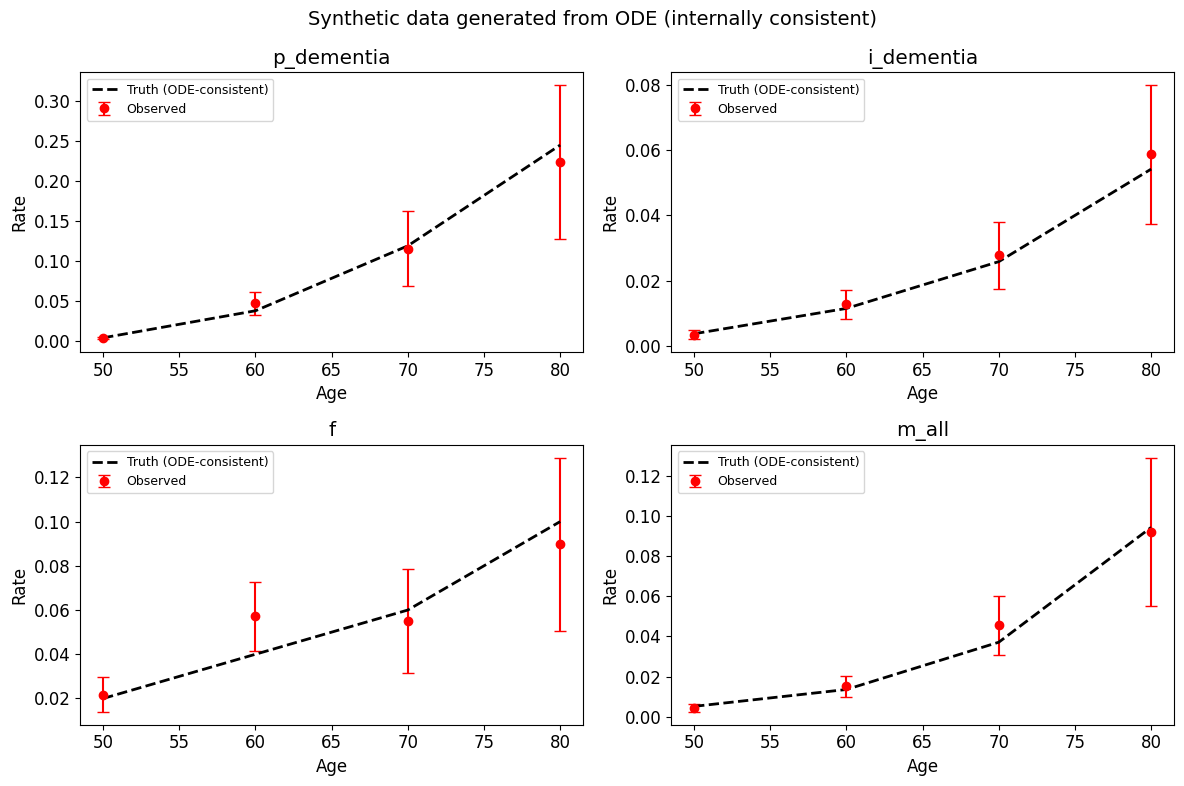

In [15]:
# Generate ODE-CONSISTENT synthetic data for the full model demo.
# Key insight: we pick transition rates and initial conditions, then solve the
# ODE forward to derive prevalences and incidence that are internally consistent.

full_ages = np.array([50, 60, 70, 80])
n_ages = len(full_ages)
dt_step = 10.0  # years between age knots

# "True" transition rates (we choose these freely)
true_h_S_to_BBBM = np.array([0.010, 0.025, 0.050, 0.080])
true_f             = np.array([0.020, 0.040, 0.060, 0.100])
true_m             = np.array([0.005, 0.012, 0.030, 0.070])

# Initial compartment fractions at age 50
true_p0 = 0.02           # total disease prevalence
true_delta_BBBM0 = 0.50  # half of prevalent cases are in BBBM
true_delta_MCI0  = 0.30  # 30% in MCI
S0_init = 1.0 - true_p0
BBBM0_init = true_p0 * true_delta_BBBM0
MCI0_init  = true_p0 * true_delta_MCI0
D0_init    = true_p0 * (1 - true_delta_BBBM0 - true_delta_MCI0)

# Solve ODE forward from each age knot to derive consistent values
true_p = np.zeros(n_ages)
true_delta_BBBM = np.zeros(n_ages)
true_delta_MCI = np.zeros(n_ages)
true_p_dementia = np.zeros(n_ages)
true_i_dementia = np.zeros(n_ages)
true_m_all = np.zeros(n_ages)


def integrate_one_interval(S, BBBM, MCI, D, h_S, f_, m_):
    """Integrate the 4-compartment ODE forward by one age step (dt_step years)."""
    sol = diffeqsolve(
        ODETerm(ode_rhs), Dopri5(),
        t0=0.0, t1=dt_step, dt0=0.5,
        y0=(S, BBBM, MCI, D, 0.0),
        saveat=SaveAt(t0=False, t1=True),
        args=[h_S, h_BBBM_to_MCI, h_MCI_to_D, f_, m_],
    )
    return (
        float(sol.ys[0][0]),  # S_next
        float(sol.ys[1][0]),  # BBBM_next
        float(sol.ys[2][0]),  # MCI_next
        float(sol.ys[3][0]),  # D_next
        float(sol.ys[4][0]),  # cumulative new_D over the interval
    )


# Set initial values at age 50
S_cur, BBBM_cur, MCI_cur, D_cur = S0_init, BBBM0_init, MCI0_init, D0_init
for k in range(n_ages):
    alive = S_cur + BBBM_cur + MCI_cur + D_cur
    disease = BBBM_cur + MCI_cur + D_cur
    true_p[k] = disease / alive
    true_delta_BBBM[k] = BBBM_cur / disease if disease > 0 else 0.33
    true_delta_MCI[k]  = MCI_cur / disease if disease > 0 else 0.33
    true_p_dementia[k] = D_cur / alive
    true_m_all[k] = true_m[k] + true_f[k] * true_p_dementia[k]

    # The "true" incidence at age k is defined as the average incidence rate
    # across the interval [age_k, age_{k+1}] -- this matches how the
    # consistency constraint interprets inc[k] in model_full_ode.  For the
    # last age (80), we integrate 80 -> 90 to get the same interval-average
    # without advancing S_cur/BBBM_cur/... past the data grid.
    S_n, BBBM_n, MCI_n, D_n, new_D = integrate_one_interval(
        S_cur, BBBM_cur, MCI_cur, D_cur,
        true_h_S_to_BBBM[k], true_f[k], true_m[k],
    )
    alive_next = S_n + BBBM_n + MCI_n + D_n
    true_i_dementia[k] = new_D / (dt_step * alive_next)

    if k < n_ages - 1:
        S_cur, BBBM_cur, MCI_cur, D_cur = S_n, BBBM_n, MCI_n, D_n

# Collect all true rates
true_rates = {
    'p_dementia': true_p_dementia,
    'i_dementia': true_i_dementia,
    'f': true_f,
    'm_all': true_m_all,
}
true_latent = {
    'h_S_to_BBBM': true_h_S_to_BBBM,
    'delta_BBBM': true_delta_BBBM,
    'delta_MCI': true_delta_MCI,
}

# Generate noisy observations from the consistent truth (SE = 20% of the rate)
obs_data = {}
for key, truth in true_rates.items():
    se = 0.2 * truth
    mean = np.clip(truth + rng.normal(0, se), 1e-6, 1)
    obs_data[key] = {'mean': mean, 'se': se}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, key in zip(axes.ravel(), true_rates.keys()):
    ax.errorbar(full_ages, obs_data[key]['mean'],
                yerr=1.96*obs_data[key]['se'], fmt='ro', capsize=4, label='Observed')
    ax.plot(full_ages, true_rates[key], 'k--', lw=2, label='Truth (ODE-consistent)')
    ax.set(xlabel='Age', ylabel='Rate', title=key)
    ax.legend(fontsize=9)
plt.suptitle('Synthetic data generated from ODE (internally consistent)', fontsize=14)
plt.tight_layout()

print("True rates are ODE-consistent by construction:")
for key in true_rates:
    vals = ', '.join(f'{v:.4f}' for v in true_rates[key])
    print(f"  {key}: [{vals}]")

In [16]:
def model_full_ode(include_consistency=True):
    """Full model matching the structure of consistent_rates.py"""
    n = n_ages

    # Priors on all 7 rate functions: Uniform(0, 1), matching Parts 1 and 2.
    p = numpyro.sample("p", dist.Uniform(
        jnp.zeros(n), jnp.ones(n)))
    delta_BBBM = numpyro.sample("delta_BBBM", dist.Uniform(
        jnp.zeros(n), jnp.ones(n)))
    delta_MCI = numpyro.sample("delta_MCI", dist.Uniform(
        jnp.zeros(n), jnp.ones(n)))
    h = numpyro.sample("h_S_to_BBBM", dist.Uniform(
        jnp.zeros(n), jnp.ones(n)))
    inc = numpyro.sample("i", dist.Uniform(
        jnp.zeros(n), jnp.ones(n)))
    f = numpyro.sample("f", dist.Uniform(
        jnp.zeros(n), jnp.ones(n)))
    m = numpyro.sample("m", dist.Uniform(
        jnp.zeros(n), jnp.ones(n)))

    # --- Derived quantity: dementia prevalence ---
    p_dementia = p * (1 - delta_BBBM - delta_MCI)

    # --- Data likelihoods ---
    numpyro.sample("p_dementia_obs", dist.Normal(
        p_dementia, jnp.array(obs_data['p_dementia']['se'])),
        obs=jnp.array(obs_data['p_dementia']['mean']))

    numpyro.sample("i_obs", dist.Normal(
        inc, jnp.array(obs_data['i_dementia']['se'])),
        obs=jnp.array(obs_data['i_dementia']['mean']))

    numpyro.sample("f_obs", dist.Normal(
        f, jnp.array(obs_data['f']['se'])),
        obs=jnp.array(obs_data['f']['mean']))

    # m_all = m + f * p_dementia  (population-level CSMR relationship)
    m_all = m + f * p_dementia
    numpyro.sample("m_all_obs", dist.Normal(
        m_all, jnp.array(obs_data['m_all']['se'])),
        obs=jnp.array(obs_data['m_all']['mean']))

    if not include_consistency:
        return

    # --- ODE consistency constraints ---
    sigma = 0.005
    dt_step = 10.0  # age-group width
    eps = 1e-12

    def check_one_interval(k):
        """Check ODE consistency for age interval k -> k+1."""
        # Initialize from estimated rates at age k
        S0 = 1.0 - p[k]
        BBBM0 = p[k] * delta_BBBM[k]
        MCI0 = p[k] * delta_MCI[k]
        D0 = p[k] * (1 - delta_BBBM[k] - delta_MCI[k])

        sol = diffeqsolve(
            ODETerm(ode_rhs), Dopri5(),
            t0=0.0, t1=dt_step, dt0=0.5,
            y0=(S0, BBBM0, MCI0, D0, 0.0),
            saveat=SaveAt(t0=False, t1=True),
            args=[h[k], h_BBBM_to_MCI, h_MCI_to_D, f[k], m[k]],
        )

        # SaveAt(t1=True) saves one time point, so each entry of sol.ys is a
        # length-1 JAX array.  Index [0] to extract the scalar at t1 so that
        # the downstream error is also a scalar.
        S1    = sol.ys[0][0]
        BBBM1 = sol.ys[1][0]
        MCI1  = sol.ys[2][0]
        D1    = sol.ys[3][0]
        new_D1 = sol.ys[4][0]
        alive = S1 + BBBM1 + MCI1 + D1
        disease = BBBM1 + MCI1 + D1

        # Compare ODE-predicted state at age k+1 to model estimates at k+1
        err = 0.0
        err += (jnp.log(jnp.clip(BBBM1 / (disease + eps), eps))
                - jnp.log(jnp.clip(delta_BBBM[k+1], eps))) ** 2
        err += (jnp.log(jnp.clip(MCI1 / (disease + eps), eps))
                - jnp.log(jnp.clip(delta_MCI[k+1], eps))) ** 2
        err += (jnp.log(jnp.clip(D1 / (alive + eps), eps))
                - jnp.log(jnp.clip(p_dementia[k+1], eps))) ** 2
        # Incidence: the ODE accumulates new cases DURING the interval
        # [age_k, age_k+1], so compare to inc[k] -- the rate that applies
        # during the interval.  (The production code does the same via
        # i(a + dt/2) which maps back to the current age bin.)
        err += (jnp.log(jnp.clip(new_D1 / (dt_step * (alive + eps)), eps))
                - jnp.log(jnp.clip(inc[k], eps))) ** 2
        return jnp.sqrt(err)

    # Apply consistency at each age interval
    for k in range(n - 1):
        ode_error = check_one_interval(k)
        numpyro.deterministic(f"ode_error_{k}", ode_error)
        numpyro.factor(f"ode_consistency_{k}",
                       dist.Normal(0, sigma).log_prob(ode_error))

In [17]:
# Fit the model WITHOUT consistency (just priors + data)
kernel = infer.NUTS(
    lambda: model_full_ode(include_consistency=False),
    init_strategy=infer.init_to_value(values={
        "p": jnp.ones(n_ages) * 0.05,
        "delta_BBBM": jnp.ones(n_ages) * 0.3,
        "delta_MCI": jnp.ones(n_ages) * 0.3,
        "h_S_to_BBBM": jnp.ones(n_ages) * 0.03,
        "i": jnp.array(obs_data['i_dementia']['mean']),
        "f": jnp.array(obs_data['f']['mean']),
        "m": jnp.array(obs_data['m_all']['mean']),
    }),
)
mcmc_no = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=1, progress_bar=False)
mcmc_no.run(jax.random.PRNGKey(2))
samples_no = mcmc_no.get_samples()

In [18]:
# Fit the model WITH consistency constraints
kernel = infer.NUTS(
    lambda: model_full_ode(include_consistency=True),
    init_strategy=infer.init_to_value(values={
        "p": jnp.ones(n_ages) * 0.05,
        "delta_BBBM": jnp.ones(n_ages) * 0.3,
        "delta_MCI": jnp.ones(n_ages) * 0.3,
        "h_S_to_BBBM": jnp.ones(n_ages) * 0.03,
        "i": jnp.array(obs_data['i_dementia']['mean']),
        "f": jnp.array(obs_data['f']['mean']),
        "m": jnp.array(obs_data['m_all']['mean']),
    }),
)
mcmc_yes = infer.MCMC(kernel, num_warmup=200, num_samples=200, num_chains=1, progress_bar=False)
mcmc_yes.run(jax.random.PRNGKey(2))
samples_yes = mcmc_yes.get_samples()

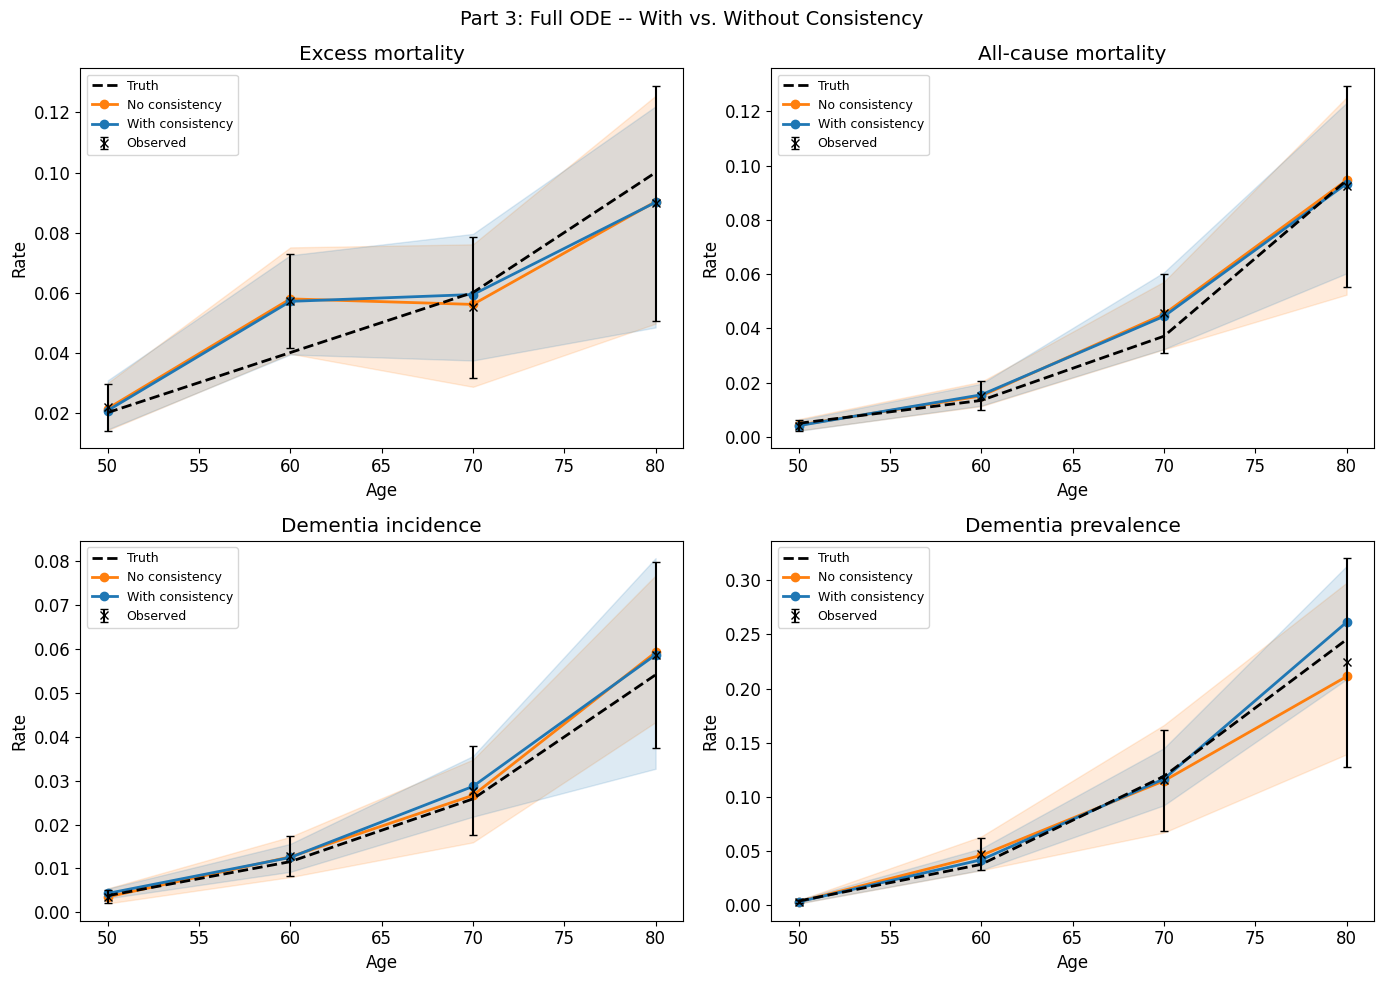

In [19]:
# Compare the two fits across observable rates
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_params = [
    ('f', 'Excess mortality'),
    ('m_all', 'All-cause mortality'),
    ('i', 'Dementia incidence'),
    ('p_dementia', 'Dementia prevalence'),
]

for ax, (key, title) in zip(axes.ravel(), plot_params):
    # Get posterior samples for this quantity
    if key == 'p_dementia':
        samp_no = np.array(samples_no['p'] * (1 - samples_no['delta_BBBM'] - samples_no['delta_MCI']))
        samp_yes = np.array(samples_yes['p'] * (1 - samples_yes['delta_BBBM'] - samples_yes['delta_MCI']))
    elif key == 'm_all':
        p_dem_no = samples_no['p'] * (1 - samples_no['delta_BBBM'] - samples_no['delta_MCI'])
        samp_no = np.array(samples_no['m'] + samples_no['f'] * p_dem_no)
        p_dem_yes = samples_yes['p'] * (1 - samples_yes['delta_BBBM'] - samples_yes['delta_MCI'])
        samp_yes = np.array(samples_yes['m'] + samples_yes['f'] * p_dem_yes)
    elif key == 'i':
        samp_no = np.array(samples_no['i'])
        samp_yes = np.array(samples_yes['i'])
    else:
        samp_no = np.array(samples_no[key])
        samp_yes = np.array(samples_yes[key])

    # Observed data key mapping
    obs_key = key if key != 'i' else 'i_dementia'

    # Plot truth
    ax.plot(full_ages, true_rates[obs_key], 'k--', lw=2, label='Truth', zorder=6)

    # Plot observed data
    ax.errorbar(full_ages, obs_data[obs_key]['mean'],
                yerr=1.96*obs_data[obs_key]['se'], fmt='kx', capsize=3,
                label='Observed', zorder=5)

    for samp, color, label in [(samp_no, 'tab:orange', 'No consistency'),
                                (samp_yes, 'tab:blue', 'With consistency')]:
        med = np.median(samp, axis=0)
        lo = np.percentile(samp, 2.5, axis=0)
        hi = np.percentile(samp, 97.5, axis=0)
        ax.plot(full_ages, med, 'o-', color=color, lw=2, label=label)
        ax.fill_between(full_ages, lo, hi, alpha=0.15, color=color)

    ax.set(xlabel='Age', ylabel='Rate', title=title)
    ax.legend(fontsize=9)

plt.suptitle('Part 3: Full ODE -- With vs. Without Consistency', fontsize=14)
plt.tight_layout()

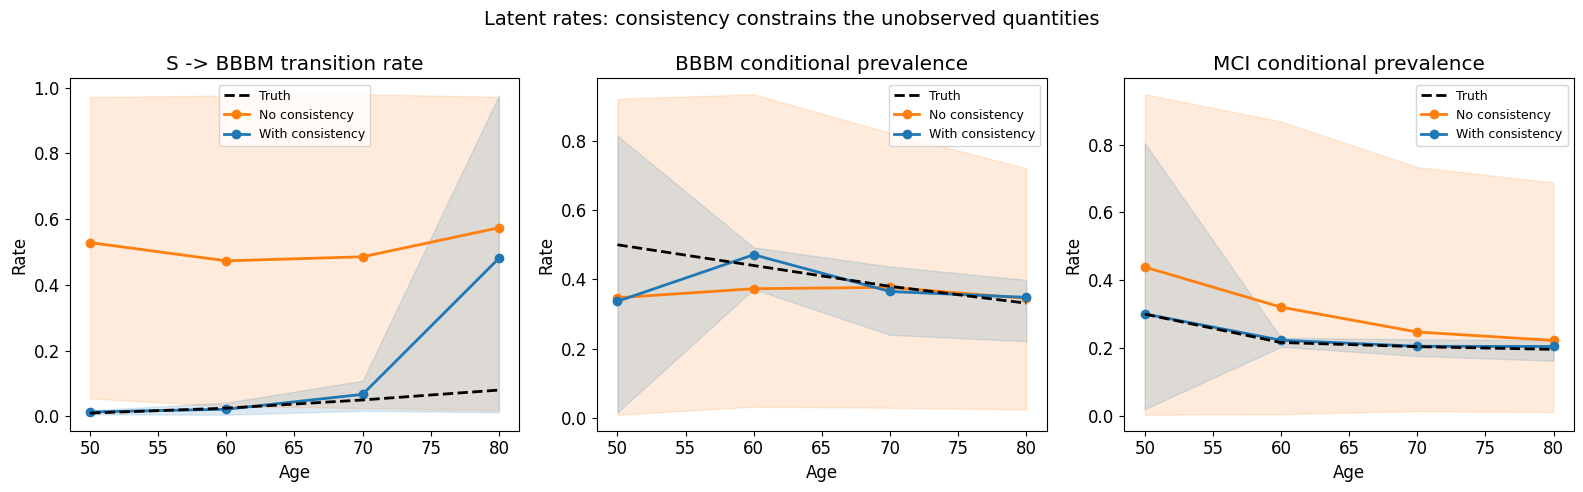

In [20]:
# Show the latent (unobserved) rates that the model also estimates
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

latent_params = [
    ('h_S_to_BBBM', 'S -> BBBM transition rate'),
    ('delta_BBBM', 'BBBM conditional prevalence'),
    ('delta_MCI', 'MCI conditional prevalence'),
]

for ax, (key, title) in zip(axes, latent_params):
    # Plot truth
    ax.plot(full_ages, true_latent[key], 'k--', lw=2, label='Truth', zorder=6)

    for samp_dict, color, label in [(samples_no, 'tab:orange', 'No consistency'),
                                     (samples_yes, 'tab:blue', 'With consistency')]:
        samp = np.array(samp_dict[key])
        med = np.median(samp, axis=0)
        lo = np.percentile(samp, 2.5, axis=0)
        hi = np.percentile(samp, 97.5, axis=0)
        ax.plot(full_ages, med, 'o-', color=color, lw=2, label=label)
        ax.fill_between(full_ages, lo, hi, alpha=0.15, color=color)
    ax.set(xlabel='Age', ylabel='Rate', title=title)
    ax.legend(fontsize=9)

plt.suptitle('Latent rates: consistency constrains the unobserved quantities', fontsize=14)
plt.tight_layout()

**Key observation:** Without consistency, the latent rates (`h_S_to_BBBM`, `delta_BBBM`,
`delta_MCI`) are only weakly constrained by the data -- their posteriors are wide.
With the ODE consistency constraint, they narrow substantially because the ODE
links them to the observed rates.

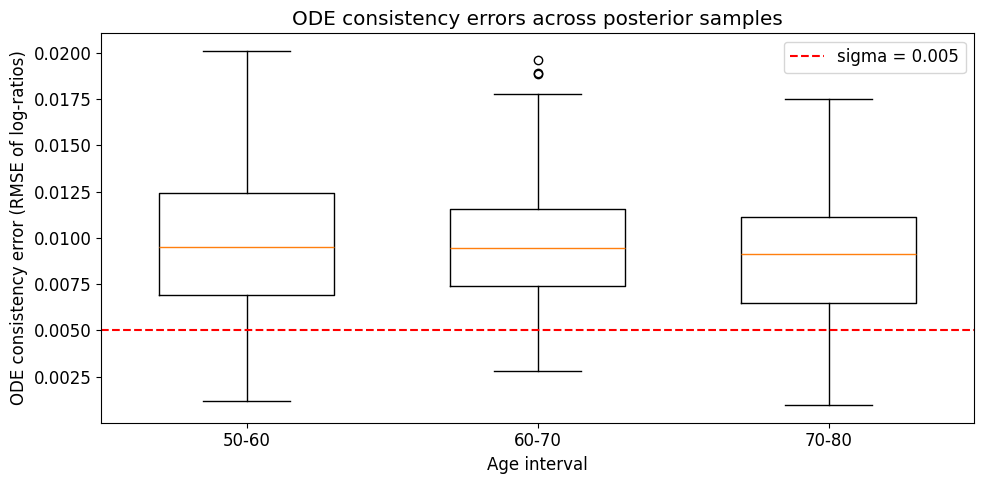

In [21]:
# Quantify ODE consistency errors for the "with consistency" model
if any(k.startswith('ode_error_') for k in samples_yes.keys()):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for k in range(n_ages - 1):
        err_key = f"ode_error_{k}"
        if err_key in samples_yes:
            err = np.array(samples_yes[err_key])
            bp = ax.boxplot(err, positions=[k], widths=0.6)
    
    ax.set_xticks(range(n_ages - 1))
    ax.set_xticklabels([f"{full_ages[k]}-{full_ages[k+1]}" for k in range(n_ages - 1)])
    ax.set(xlabel='Age interval', ylabel='ODE consistency error (RMSE of log-ratios)',
           title='ODE consistency errors across posterior samples')
    ax.axhline(0.005, color='red', ls='--', label='sigma = 0.005')
    ax.legend()
    plt.tight_layout()
else:
    print("ODE error deterministics not stored -- this is normal if using vmap.")
    print("The consistency constraint is still enforced via numpyro.factor().")

---
## Summary: How `consistent_rates.py` Works

| Concept | Where in the code | What we showed |
|---|---|---|
| **Vague prior** on each rate | `numpyro.sample("p", Uniform(0, 1))` | Part 1: single rate prior |
| **Piecewise-constant interpolation** | `at_param()` function | Creates `f(age, time)` from knot values |
| **Gaussian likelihood** | `data_model()` function | Part 1: `numpyro.sample(..., obs=data)` |
| **Derived quantities** | `p_dementia = p * (1 - delta_BBBM - delta_MCI)` | Dementia prevalence from sub-state fractions |
| **Population mortality** | `m_all = m + f * p_dementia` | All-cause mortality includes excess |
| **Difference-equation consistency** | `prev[k+1] vs prev[k] + da*inc[k]*(1-prev[k])` | Part 2: two-rate consistency |
| **ODE forward integration** | `diffeqsolve()` with `Dopri5` solver | Part 3: integrate compartments forward |
| **Consistency penalty** | `numpyro.factor("ode_consistency", ...)` | Part 2 (simple) and Part 3 (full) |
| **Log-ratio error metric** | `(log(ODE_pred) - log(model_est))^2` | Penalizes proportional disagreement |
| **MCMC inference** | `NUTS` sampler with `init_to_value` | All parts: posterior samples balance data + consistency |

### The key insight

The consistency constraint encodes **biological reality**: you can't have
rising prevalence without sufficient incidence, and you can't have people
accumulating in BBBM without the right transition rate from Susceptible.
By penalizing inconsistency -- a one-line difference equation in Part 2, a
full 4-compartment ODE in Part 3 -- the model borrows strength across all
the rates simultaneously, producing estimates that are not only close to
the data but also *internally coherent*.